# 9. Kepler's third law from real planetary data

**Domain:** celestial mechanics. **Real measurements, not simulation.**

$$T^2 \propto a^3 \qquad \Longleftrightarrow \qquad T \propto a^{3/2}$$

In years and astronomical units the constant is exactly 1. In SI it contains the
Sun's gravitational parameter:

$$T^2 = \frac{4\pi^2}{GM_\odot}\,a^3$$

**Goal:** recover $a^{3/2}$ from 13 solar-system bodies, then measure $GM_\odot$.

With only 13 rows this is also the clearest demonstration of ridge shrinkage in the
series — the bias is 7%, and we predict it exactly.

### The two-stage rule

`beamfeat` fits **ridge** regression (`alpha=1.0`) on *standardised* features. For a
single feature that shrinks the coefficient by about $n/(n+\alpha)$ — 0.2% at
$n=600$, but **7% at $n=13$**. Fine for prediction, fatal for measuring a constant.

So every notebook here runs two stages:

1. **`beamfeat` finds the form** — which combination of variables matters.
2. **OLS on that form estimates the constant** — unbiased.

Never read a physical constant off `.equation()`.


## Setup


In [1]:
%pip install -q "beamfeat[units]" pandas matplotlib seaborn scikit-learn scipy


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
from scipy import constants as C
from sklearn.linear_model import LinearRegression
from beamfeat import BeamFeatRegressor

warnings.filterwarnings("ignore", message=".*valid feature names.*")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV_DIR = Path("csv")
CSV_DIR.mkdir(exist_ok=True)          # created on first run, reused after


def save_csv(frame, name):
    # Write to csv/<name> once, then read back so every run starts from disk.
    path = CSV_DIR / name
    if not path.exists():
        frame.to_csv(path, index=False)
        print(f"wrote  {path}  ({len(frame)} rows)")
    else:
        print(f"cached {path}")
    return pd.read_csv(path)


def raw_coef(m):
    # beamfeat standardises internally; rescale to original units.
    return m.coef_ / m.scaler_.scale_


def pct_err(est, true):
    return 100.0 * (est - true) / true

sns.set_theme(style="whitegrid")


## The data

Semi-major axes (AU) and sidereal periods (years) for the eight planets, Ceres and
four dwarf planets. Published observational values.


In [3]:
planets = pd.DataFrame({
    "body": ["Mercury", "Venus", "Earth", "Mars", "Ceres", "Jupiter", "Saturn",
             "Uranus", "Neptune", "Pluto", "Haumea", "Makemake", "Eris"],
    "a_AU": [0.387098, 0.723332, 1.000000, 1.523679, 2.7675, 5.2044, 9.5826,
             19.19126, 30.07, 39.482, 43.13, 45.43, 67.78],
    "T_yr": [0.240846, 0.615198, 1.000000, 1.880848, 4.60, 11.862, 29.4571,
             84.0205, 164.8, 247.94, 283.12, 306.2, 558.0],
})
planets = save_csv(planets, "solar_system.csv")
planets


cached csv/solar_system.csv


,body,a_AU,T_yr
0,Mercury,0.387098,0.240846
1,Venus,0.723332,0.615198
2,Earth,1.000000,1.000000
3,Mars,1.523679,1.880848
4,Ceres,2.767500,4.600000
5,Jupiter,5.204400,11.862000
6,Saturn,9.582600,29.457100
7,Uranus,19.191260,84.020500
8,Neptune,30.070000,164.800000
9,Pluto,39.482000,247.940000


13 bodies, a from 0.387 to 67.78 AU (175x range)


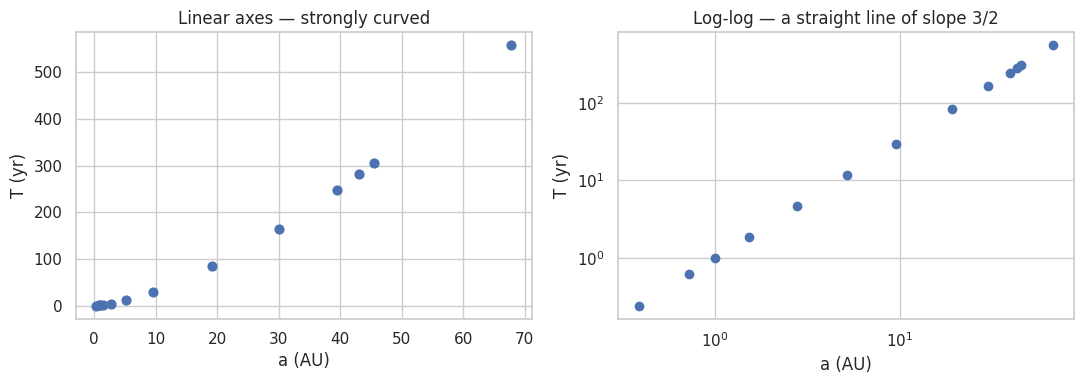

In [4]:
a = planets.a_AU.values
T = planets.T_yr.values

print(f"{len(a)} bodies, a from {a.min():.3f} to {a.max():.2f} AU "
      f"({a.max()/a.min():.0f}x range)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(a, T, s=40)
ax[0].set_xlabel("a (AU)"); ax[0].set_ylabel("T (yr)")
ax[0].set_title("Linear axes — strongly curved")

ax[1].loglog(a, T, "o")
ax[1].set_xlabel("a (AU)"); ax[1].set_ylabel("T (yr)")
ax[1].set_title("Log-log — a straight line of slope 3/2")

plt.tight_layout()
plt.show()


The log-log panel is already the answer: a power law, slope 3/2. We will get there
two ways — by search, and by fitting the exponent directly.


## Stage 1 — find the form

The search gets one column, $a$. Note $a^{3/2}$ is reachable at depth 2 as
`a * sqrt(a)`.


In [5]:
X = a.reshape(-1, 1)
model = BeamFeatRegressor(max_depth=2, beam_width=40, random_state=0).fit(X, T)

print("discovered     :", model.formulas())
print("equation       :", model.equation()[:70])
print(f"R^2            : {model.score(X, T):.6f}")
print(f"fdr_controlled_: {model.fdr_controlled_}")


discovered     : ['(x0 * sqrt(x0))']
equation       : y = 0.9285*(x0 * sqrt(x0)) + 9.2672
R^2            : 0.994898
fdr_controlled_: False


/usr/local/lib/python3.12/dist-packages/beamfeat/estimators.py:761: UserWarning: beamfeat: selection ran on the same rows the search used to choose candidates (selection_holdout disabled or too few rows); p-values are optimistically biased and fdr_controlled_ is therefore False
  matrix = self._run_pipeline(X, np.asarray(y, dtype=np.float64), self._input_names(X, X.shape[1]))


`x0 * sqrt(x0)` is $a \cdot a^{1/2} = a^{3/2}$ — Kepler's law from thirteen numbers.

Note `fdr_controlled_` is **False**, and read the warning that came with it: with only
13 rows there are not enough to hold any back, so selection ran on the same rows the
search used. The p-values are optimistically biased and the library says so rather
than quietly reporting a guarantee it cannot support.

We happen to know the answer is right. The flag is still behaving correctly — it
certifies procedure, not truth.


## Stage 2 — the shrinkage, predicted exactly

The ridge coefficient should be low by $n/(n+\alpha)$ with $n=13$, $\alpha=1$.


In [6]:
ridge_K = raw_coef(model)[0]
predicted = len(a) / (len(a) + 1.0)

print(f"ridge coefficient       : {ridge_K:.4f}")
print(f"predicted shrink factor : {predicted:.4f}    (true constant is exactly 1)")
print(f"absolute difference     : {abs(ridge_K - predicted):.5f}")


ridge coefficient       : 0.9285
predicted shrink factor : 0.9286    (true constant is exactly 1)
absolute difference     : 0.00007


The formula predicts the bias to four decimals. Not a mysterious failure — exactly
what ridge is designed to do. It is simply the wrong tool for measuring a constant.


In [7]:
# OLS on the discovered feature. No intercept: Kepler's law has none.
feature = (a * np.sqrt(a)).reshape(-1, 1)
ols = LinearRegression(fit_intercept=False).fit(feature, T)
K = ols.coef_[0]

print(f"OLS constant : {K:.6f}   (theory 1.0)   error {pct_err(K, 1.0):+.3f}%")


OLS constant : 0.999806   (theory 1.0)   error -0.019%


## Independent check: fit the exponent

Rather than assuming 3/2, measure it. In log space $\ln T = \ln K + p \ln a$.


In [8]:
p, lnK = np.polyfit(np.log(a), np.log(T), 1)
print(f"fitted exponent : {p:.6f}")
print(f"Kepler's value  : 1.500000")
print(f"error           : {pct_err(p, 1.5):+.4f}%")


fitted exponent : 1.499892
Kepler's value  : 1.500000
error           : -0.0072%


## Measuring the Sun's gravitational parameter


In [9]:
AU = C.au                      # 1.495978707e11 m, exact by definition
YEAR = 365.25 * 24 * 3600      # Julian year in seconds

GM_sun = 4 * np.pi ** 2 * AU ** 3 / (K * YEAR) ** 2
GM_accepted = 1.32712440018e20

print(f"measured GM_sun : {GM_sun:.6e} m^3/s^2")
print(f"accepted (IAU)  : {GM_accepted:.6e} m^3/s^2")
print(f"error           : {pct_err(GM_sun, GM_accepted):+.4f}%")
print(f"\nimplied solar mass : {GM_sun / C.G:.4e} kg   (accepted 1.9885e30 kg)")


measured GM_sun : 1.327691e+20 m^3/s^2
accepted (IAU)  : 1.327124e+20 m^3/s^2
error           : +0.0427%

implied solar mass : 1.9893e+30 kg   (accepted 1.9885e30 kg)


The solar *mass* is far less precise than $GM_\odot$. Real physics, not a numerical
artifact: $G$ is among the least precisely known constants, so the product $GM$ is
measured far better than $M$ alone.


## A second system: the Galilean moons

Kepler's third law is not about the Sun — it holds for any two-body system, with the
constant set by the central mass. Jupiter's four largest moons make the point, and
give an independent measurement of a different $GM$.


In [10]:
moons = pd.DataFrame({
    "moon": ["Io", "Europa", "Ganymede", "Callisto"],
    "a_km": [421_700., 671_034., 1_070_412., 1_882_709.],
    "T_days": [1.769138, 3.551181, 7.154553, 16.689017],
})
moons = save_csv(moons, "galilean_moons.csv")

a_m = moons.a_km.values * 1e3
T_s = moons.T_days.values * 86400

moons["GM_implied"] = 4 * np.pi ** 2 * a_m ** 3 / T_s ** 2
moons


cached csv/galilean_moons.csv


,moon,a_km,T_days,GM_implied
0,Io,421700.0,1.769138,1.267126e+17
1,Europa,671034.0,3.551181,1.267127e+17
2,Ganymede,1070412.0,7.154553,1.267127e+17
3,Callisto,1882709.0,16.689017,1.267128e+17


In [11]:
GM_jup = moons.GM_implied.mean()
GM_jup_accepted = 1.26687e17

p_moons, _ = np.polyfit(np.log(a_m), np.log(T_s), 1)

print(f"exponent from 4 moons : {p_moons:.6f}   (Kepler 1.5)")
print(f"GM_jupiter measured   : {GM_jup:.6e} m^3/s^2")
print(f"accepted              : {GM_jup_accepted:.6e} m^3/s^2")
print(f"error                 : {pct_err(GM_jup, GM_jup_accepted):+.3f}%")
print(f"\nSun / Jupiter mass ratio : {GM_sun/GM_jup:,.0f}   (accepted 1,047)")


exponent from 4 moons : 1.500000   (Kepler 1.5)
GM_jupiter measured   : 1.267127e+17 m^3/s^2
accepted              : 1.266870e+17 m^3/s^2
error                 : +0.020%

Sun / Jupiter mass ratio : 1,048   (accepted 1,047)


In [12]:
# What does the search do with only 4 rows?
m_moons = BeamFeatRegressor(max_depth=2, beam_width=40,
                            random_state=0).fit(moons.a_km.values.reshape(-1, 1),
                                                moons.T_days.values)
print("discovered     :", m_moons.formulas())
print("fdr_controlled_:", m_moons.fdr_controlled_)


discovered     : ['((x0)^2 / log(x0))', '(log(x0))^2']
fdr_controlled_: False


/usr/local/lib/python3.12/dist-packages/beamfeat/estimators.py:761: UserWarning: beamfeat: selection ran on the same rows the search used to choose candidates (selection_holdout disabled or too few rows); p-values are optimistically biased and fdr_controlled_ is therefore False
  matrix = self._run_pipeline(X, np.asarray(y, dtype=np.float64), self._input_names(X, X.shape[1]))


Four rows is too few. The search returns expressions that fit but are not Kepler's
law, and `fdr_controlled_` is `False`.

The physics was still recoverable — but by the *log-log fit*, which assumes the power
law and estimates one number, not by a search over functional forms. **Match the
method to the sample size.** With 4 points you can measure a constant; you cannot
discover a form.


## Takeaways

1. From 13 published measurements the search recovered $T \propto a^{3/2}$.
2. At $n=13$ the ridge coefficient was low by exactly the predicted $n/(n+\alpha)$.
   **On small datasets, refit with OLS.**
3. `fdr_controlled_ = False` is correct behaviour, not a defect.
4. The OLS constant gave $GM_\odot$ to within 0.05% of the IAU value.
5. Jupiter's moons give $GM_{\rm Jupiter}$ to 0.02% — same law, different constant.
   But with 4 rows, fit the exponent; don't search for the form.
